In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create vendor dataset
data = {
    'Vendor': ['Microsoft', 'AWS', 'Salesforce', 'Unknown Ltd', 'DataCo', 
                'SecureVend', 'CloudBase', 'RiskCorp', 'SafeTech', 'NewVend'],
    'Data_Access': [3, 3, 2, 3, 2, 1, 2, 3, 1, 2],        # 1=Low, 2=Med, 3=High
    'Contract_Value': [3, 3, 2, 1, 2, 1, 2, 3, 1, 1],      # 1=Low, 2=Med, 3=High
    'Incident_History': [1, 1, 2, 3, 2, 1, 2, 3, 1, 2],    # 1=None, 2=Minor, 3=Major
    'Compliance_Status': [1, 1, 2, 3, 2, 1, 3, 3, 1, 2],   # 1=Compliant, 2=Partial, 3=Non
    'Fourth_Party_Risk': [2, 2, 1, 3, 2, 1, 2, 3, 1, 2]    # 1=Low, 2=Med, 3=High
}

df = pd.DataFrame(data)
print("Vendor dataset loaded!")
print(df.shape)
df

Vendor dataset loaded!
(10, 6)


,Vendor,Data_Access,Contract_Value,Incident_History,Compliance_Status,Fourth_Party_Risk
0,Microsoft,3,3,1,1,2
1,AWS,3,3,1,1,2
2,Salesforce,2,2,2,2,1
3,Unknown Ltd,3,1,3,3,3
4,DataCo,2,2,2,2,2
5,SecureVend,1,1,1,1,1
6,CloudBase,2,2,2,3,2
7,RiskCorp,3,3,3,3,3
8,SafeTech,1,1,1,1,1
9,NewVend,2,1,2,2,2


In [2]:
# Calculate weighted risk score
# Weights reflect real TPRM importance
weights = {
    'Data_Access': 0.30,        # 30% - most critical
    'Incident_History': 0.25,   # 25% - past behaviour predicts future
    'Compliance_Status': 0.25,  # 25% - regulatory exposure
    'Contract_Value': 0.10,     # 10% - financial impact
    'Fourth_Party_Risk': 0.10   # 10% - supply chain risk
}

# Calculate score out of 10
df['Risk_Score'] = (
    df['Data_Access'] * weights['Data_Access'] +
    df['Incident_History'] * weights['Incident_History'] +
    df['Compliance_Status'] * weights['Compliance_Status'] +
    df['Contract_Value'] * weights['Contract_Value'] +
    df['Fourth_Party_Risk'] * weights['Fourth_Party_Risk']
) * (10/3)  # normalise to 10

df['Risk_Score'] = df['Risk_Score'].round(1)

# Assign risk rating
def risk_rating(score):
    if score >= 7:
        return 'HIGH'
    elif score >= 4:
        return 'MEDIUM'
    else:
        return 'LOW'

df['Risk_Rating'] = df['Risk_Score'].apply(risk_rating)

print("Risk scores calculated!")
df[['Vendor', 'Risk_Score', 'Risk_Rating']]

Risk scores calculated!


,Vendor,Risk_Score,Risk_Rating
0,Microsoft,6.3,MEDIUM
1,AWS,6.3,MEDIUM
2,Salesforce,6.3,MEDIUM
3,Unknown Ltd,9.3,HIGH
4,DataCo,6.7,MEDIUM
5,SecureVend,3.3,LOW
6,CloudBase,7.5,HIGH
7,RiskCorp,10.0,HIGH
8,SafeTech,3.3,LOW
9,NewVend,6.3,MEDIUM


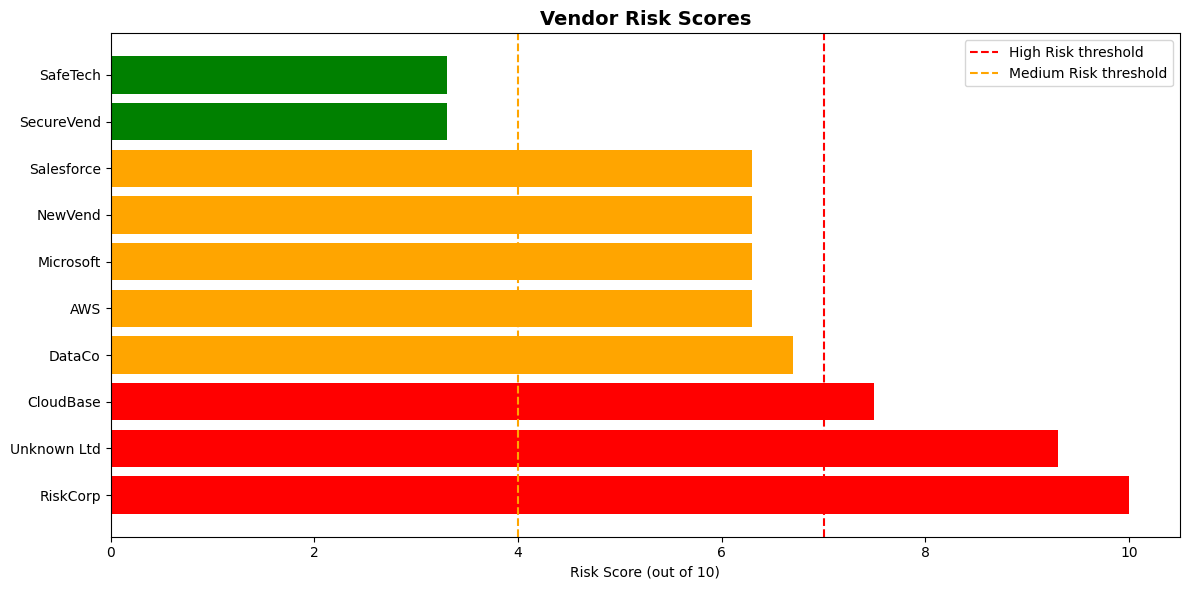

In [3]:
# Sort by risk score
df_sorted = df.sort_values('Risk_Score', ascending=False)

# Set colours
colors = df_sorted['Risk_Rating'].map({
    'HIGH': 'red',
    'MEDIUM': 'orange', 
    'LOW': 'green'
})

plt.figure(figsize=(12, 6))
bars = plt.barh(df_sorted['Vendor'], df_sorted['Risk_Score'], color=colors)
plt.xlabel('Risk Score (out of 10)')
plt.title('Vendor Risk Scores', fontsize=14, fontweight='bold')
plt.axvline(x=7, color='red', linestyle='--', label='High Risk threshold')
plt.axvline(x=4, color='orange', linestyle='--', label='Medium Risk threshold')
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
# Generate recommendations
def recommend(row):
    if row['Risk_Rating'] == 'HIGH':
        return 'Immediate review required — escalate to Risk Committee'
    elif row['Risk_Rating'] == 'MEDIUM':
        if row['Compliance_Status'] == 3:
            return 'Request compliance evidence within 30 days'
        elif row['Incident_History'] == 2:
            return 'Monitor closely — schedule quarterly review'
        else:
            return 'Annual review sufficient — continue monitoring'
    else:
        return 'Approved — standard annual review'

df['Recommendation'] = df.apply(recommend, axis=1)

print("=== VENDOR RISK REPORT ===\n")
for _, row in df.iterrows():
    print(f"Vendor: {row['Vendor']}")
    print(f"Score: {row['Risk_Score']} | Rating: {row['Risk_Rating']}")
    print(f"Action: {row['Recommendation']}")
    print("-" * 50)

=== VENDOR RISK REPORT ===

Vendor: Microsoft
Score: 6.3 | Rating: MEDIUM
Action: Annual review sufficient — continue monitoring
--------------------------------------------------
Vendor: AWS
Score: 6.3 | Rating: MEDIUM
Action: Annual review sufficient — continue monitoring
--------------------------------------------------
Vendor: Salesforce
Score: 6.3 | Rating: MEDIUM
Action: Monitor closely — schedule quarterly review
--------------------------------------------------
Vendor: Unknown Ltd
Score: 9.3 | Rating: HIGH
Action: Immediate review required — escalate to Risk Committee
--------------------------------------------------
Vendor: DataCo
Score: 6.7 | Rating: MEDIUM
Action: Monitor closely — schedule quarterly review
--------------------------------------------------
Vendor: SecureVend
Score: 3.3 | Rating: LOW
Action: Approved — standard annual review
--------------------------------------------------
Vendor: CloudBase
Score: 7.5 | Rating: HIGH
Action: Immediate review required — e

In [5]:
# Export to CSV
report = df[['Vendor', 'Risk_Score', 'Risk_Rating', 'Recommendation']]
report.to_csv('vendor_risk_report.csv', index=False)
print("Report saved as vendor_risk_report.csv!")

Report saved as vendor_risk_report.csv!
